In [1]:
import logging

logFileName='Lx'

logger = logging.getLogger(logFileName)  

logFile= logFileName+'.log' 

loglevel = logging.DEBUG
logging.basicConfig(filename=logFile
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFile)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

In [2]:
import pandas as pd
import time
import re
import glob

In [3]:
pd.set_option('display.max_rows',1111)
pd.set_option('display.max_colwidth', 111)
pd.set_option('display.max_columns', None)

In [4]:
import Lx
# from PT3S import Lx

## Beispieldaten

In [5]:
zip7File=r'testdata\Lx\20201113_151238a - 6 Logs.7z'
zip7FilesDir=r'C:\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips'

## Initialisierung mit Zips
#### es werden nur die ersten und letzten Logs pro Zip angelesen und dort auch nur die erste und letzte Zeile (deswegen mit DictReader); zum Anlesen extrahierte Logs werden wieder geloescht wenn sie nicht existierten

In [6]:
start = time.time()
lx=Lx.AppLog(zip7Files=glob.glob(zip7FilesDir+r'\*.7z'))
end = time.time()
print(end - start)

118.99636554718018


In [7]:
glob.glob(zip7FilesDir)

['C:\\3s\\Projekte\\20.278 - Actemium FBG Nachtrag 1\\04 - Logdateien\\20201113_151238\\Wol\\Log7Zips']

In [8]:
lx.lookUpDf

,zipName,logName,FirstTime,LastTime
0,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000004.log,2020-11-13 14:24:54.973,2020-11-13 14:28:56.953
1,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000401.log,2020-11-14 16:34:26.229,2020-11-14 16:38:18.084
2,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000402.log,2020-11-14 16:38:18.083,2020-11-14 16:42:09.938
3,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000403.log,2020-11-14 16:42:09.936,2020-11-14 16:46:01.789
4,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000404.log,2020-11-14 16:46:01.788,2020-11-14 16:49:53.662
5,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000802.log,2020-11-15 18:45:50.678,2020-11-15 18:49:42.568
6,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000803.log,2020-11-15 18:49:42.566,2020-11-15 18:53:34.432
7,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000804.log,2020-11-15 18:53:34.431,2020-11-15 18:57:26.344
8,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0001202.log,2020-11-16 20:33:54.776,2020-11-16 20:37:46.594
9,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0001203.log,2020-11-16 20:37:46.593,2020-11-16 20:41:38.485


In [9]:
lx.lookUpDfZips

,FirstTime,LastTime,TimespanPerLog,NumOfFiles,minFileNr,maxFileNr
zipName,,,,,,
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238a.7z,2020-11-13 14:24:54.973,2020-11-14 16:42:09.938,0 days 00:03:57.776293969,398,4,402
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238b.7z,2020-11-14 16:42:09.936,2020-11-15 18:49:42.568,0 days 00:03:55.720882205,399,403,802
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238c.7z,2020-11-15 18:49:42.566,2020-11-16 20:37:46.594,0 days 00:03:52.792050125,399,803,1202
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238d.7z,2020-11-16 20:37:46.593,2020-11-17 22:46:04.738,0 days 00:03:55.834949874,399,1203,1602
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238e.7z,2020-11-17 22:46:04.736,2020-11-18 07:14:58.532,0 days 00:03:42.874423357,137,1603,1740


#### Daten lesen (von Zips!)

In [10]:
timeStart='2020-11-13 14:24:55'
timeEnd='2020-11-13 14:24:59'
start = time.time()
df=lx.getFromZips(timeStart=timeStart,timeEnd=timeEnd) # data from Zips
end = time.time()
print(end - start)

61.36736798286438


In [11]:
df.head()

,#LogTime,LogLevel,SubSystem,Direction,ProcessTime,ID,Value,ScenTime,State,Remark
0,2020-11-13 14:24:54.973,STD,LOGGING,nan,NaT,nan,NaN,2020-11-13 15:24:52,nan,Logfilesize of /home/3sconsult/Logs/20201113_151238/20201113_0000003.log is 102964523
1,2020-11-13 14:24:54.975,STD,LOGGING,nan,NaT,nan,NaN,2020-11-13 15:24:52,nan,Free space in Log Directory: 195155144704
2,2020-11-13 14:24:55.000,INF,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Starting cycle for 2020-11-13 15:24:53.000
3,2020-11-13 14:24:55.000,INF,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Updating DFIDTs...
4,2020-11-13 14:24:55.027,STD,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Status is 0


#### Zeitreihen aus gelesenen Daten erzeugen

In [12]:
TCsdfOPC,TCsLDSIn,TCsLDSRes,TCsSirCalc=lx.getTCsFromDf(df)

In [13]:
TCsdfOPC.head()

ID,Objects.3S_STEUERUNG.3S_APP_LDS.In.LIFE,Objects.FBGL_LECK_SEG_NAME.L_6_FUD_25_BHD.SEG.RICHT.S,Objects.FBG_ESCHIEBER.6_BHD_25_MOV_07.In.ZUST,Objects.FBG_ESCHIEBER.6_ESX_25_MOV_02.In.ZUST,Objects.FBG_ESCHIEBER.6_FTV_25_MOV_04.In.ZUST,Objects.FBG_ESCHIEBER.6_FUD_25_MOV_01.In.ZUST,Objects.FBG_ESCHIEBER.6_HCX_25_MOV_06.In.ZUST,Objects.FBG_ESCHIEBER.6_WPX_25_MOV_03.In.ZUST,Objects.FBG_ESCHIEBER.7_AL1_51_MOV_100.In.ZUST,Objects.FBG_HPS.8_HND_03_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_BHD_20_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BHD_25_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BHD_26_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BID_10_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_FUD_25_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_KED_43_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_LPA_42_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_LSX_43_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_OHN_41_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_ZW1_20_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.7_AL1_51_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_ALD_44_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.7_SPV_44_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_URX_44_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_WAA_51_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_WSR_52_PTI_01.In.MW.value,Objects.FBG_MESSW.3_WAV_43_FT_01.In.MW.value,Objects.FBG_MESSW.6_BHD_20_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_22_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_25_FT_01.In.MW.value,Objects.FBG_MESSW.6_BHD_25_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_26_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_01_FT_01.In.MW.value,Objects.FBG_MESSW.6_BID_01_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_09_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_10_FT_01.In.MW.value,Objects.FBG_MESSW.6_BID_10_TT_01.In.MW.value,Objects.FBG_MESSW.6_BUV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_DIV_07_TT_01.In.MW.value,Objects.FBG_MESSW.6_EPX_23_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ESX_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_FTV_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_FUD_03_TT_Z.In.MW.value,Objects.FBG_MESSW.6_FUD_25_FT_01.In.MW.value,Objects.FBG_MESSW.6_FUD_25_TT_Z.In.MW.value,Objects.FBG_MESSW.6_GHV_03_FT_02.In.MW.value,Objects.FBG_MESSW.6_GHV_03_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HCX_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HSV_20_PTI_01.In.MW.value,Objects.FBG_MESSW.6_KED_26_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_39_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_43_FT_01.In.MW.value,Objects.FBG_MESSW.6_KED_L1_PTI_01.In.MW.value,Objects.FBG_MESSW.6_KED_L1_PTI_03.In.MW.value,Objects.FBG_MESSW.6_KED_L1_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_L2_PTI_04.In.MW.value,Objects.FBG_MESSW.6_KED_L2_TT_Z.In.MW.value,Objects.FBG_MESSW.6_LSX_43_PTI_03.In.MW.value,Objects.FBG_MESSW.6_MGX_40_PTI_01.In.MW.value,Objects.FBG_MESSW.6_MHV_01_FT_01.In.MW.value,Objects.FBG_MESSW.6_MOV_01_PTI_02.In.MW.value,Objects.FBG_MESSW.6_NGD_46_TT_01.In.MW.value,Objects.FBG_MESSW.6_OEV_39_PTI_01.In.MW.value,Objects.FBG_MESSW.6_PIV_20_PTI_01.In.MW.value,Objects.FBG_MESSW.6_PSD_03_FT_01.In.MW.value,Objects.FBG_MESSW.6_PSD_03_TT_Z.In.MW.value,Objects.FBG_MESSW.6_PSD_04_TT_Z.In.MW.value,Objects.FBG_MESSW.6_PSD_05_TT_Z.In.MW.value,Objects.FBG_MESSW.6_RGV_08_TT_01.In.MW.value,Objects.FBG_MESSW.6_ROV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_RTX_40_PTI_01.In.MW.value,Objects.FBG_MESSW.6_SNV_26_PTI_01.In.MW.value,Objects.FBG_MESSW.6_SPV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_STX_41_PTI_01.In.MW.value,Objects.FBG_MESSW.6_SWV_42_PTI_02.In.MW.value,Objects.FBG_MESSW.6_TUD_40_FT_02.In.MW.value,Objects.FBG_MESSW.6_WPX_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ZW1_01_FT_01.In.MW.value,Objects.FBG_MESSW.6_ZW1_01_TT_Z.In.MW.value,Objects.FBG_MESSW.6_ZW1_07_TT_01.In.MW.value,Objects.FBG_MESSW.6_ZW1_08_TT_01.In.MW.value,Objects.FBG_MESSW.6_ZW1_20_TT_Z.In.MW.value,Objects.FBG_MESSW.7_HKV_50_PTI_01.In.MW.value,Objects.FBG_MESSW.7_SPV_44_PTI_02.In.MW.value,Objects.FBG_MESSW.7_URX_44_PTI_03.In.MW.value,Objects.FBG_MESSW.7_URX_52_PTI_01.In.MW.value,Objects.FBG_MESSW.7_WU1_23_TT_01.In.MW.value,Objects.FBG_MESSW.8_HNA_03_P

<AxesSubplot:xlabel='ProcessTime'>

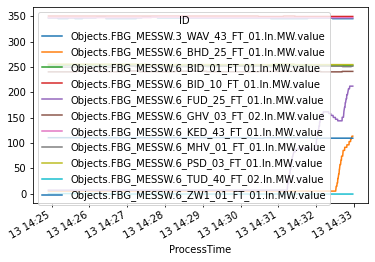

In [14]:
regExpFT=Lx.pID.pattern.replace('(?P<C4>[a-z,A-Z,0-9]+)','FT')
TCsdfOPC.filter(regex=regExpFT, axis=1).plot()

In [15]:
TCsLDSRes.head()

ID                   IMDI.Objects.3S_FBG_DRUCK.3S_1_CLC_08_PTI_01.In.ACCST_AV  \
ScenTime                                                                        
2020-11-13 15:24:53                                                       0.1   
2020-11-13 15:24:54                                                       0.1   
2020-11-13 15:24:55                                                       0.1   
2020-11-13 15:24:56                                                       0.1   
2020-11-13 15:24:57                                                       0.1   

ID                   IMDI.Objects.3S_FBG_DRUCK.3S_1_CLC_08_PTI_01.In.ACCTR_AV  \
ScenTime                                                                        
2020-11-13 15:24:53                                                       0.8   
2020-11-13 15:24:54                                                       0.8   
2020-11-13 15:24:55                                                       0.8   
2020-11-13 15:24:56                                                       0.8   
2020-11-13 15:24:57                                                       0.8   

ID                   IMDI.Objects.3S_FBG_DRUCK.3S_1_CLC_08_PTI_01.In.AC_AV  \
ScenTime                                                                     
2020-11-13 15:24:53                                                    0.0   
2020-11-13 15:24:54                                                    0.0   
2020-11-13 15:24:55                                                    0.0   
2020-11-13 15:24:56                                                    0.0   
2020-11-13 15:24:57                                                    0.0   

ID                   IMDI.Objects.3S_FBG_DRUCK.3S_1_CLC_08_PTI_01.In.QM_AV  \
ScenTime                                                                     
2020-11-13 15:24:53                                                    0.0   
2020-11-13 15:24:54                                                    0.0   
2020-11-13 15:24:55                                                    0.0   
2020-11-13 15:24:56                                                    0.0   
2020-11-13 15:24:57                                                    0.0   

ID                   IMDI.Objects.3S_FBG_DRUCK.3S_1_CLC_08_PTI_01.In.TIMER_AV  \
ScenTime                                                                        
2020-11-13 15:24:53                                                       0.0   
2020-11-13 15:24:54                                                       0.0   
2020-11-13 15:24:55                                                       0.0   
2020-11-13 15:24:56                                                       0.0   
2020-11-13 15:24:57                                                       0.0   

ID                   IMDI.Objects.3S_FBG_DRUCK.3S_4_GLD_41_PTI_01.In.ACCST_AV  \
ScenTime                                                                        
2020-11-13 15:24:53                                                       1.0   
2020-11-13 15:24:54                                                       1.0   
2020-11-13 15:24:55                                                       1.0   
2020-11-13 15:24:56                                                       1.0   
2020-11-13 15:24:57                                                       1.0   

ID                   IMDI.Objects.3S_FBG_DRUCK.3S_4_GLD_41_PTI_01.In.ACCTR_AV  \
ScenTime                                                                        
2020-11-13 15:24:53                                                       2.0   
2020-11-13 15:24:54                                                       2.0   
2020-11-13 15:24:55                                                       2.0   
2020-11-13 15:24:56                                                       2.0   
2020-11-13 15:24:57                                                       2.0   

ID                   IMDI.Objects.3S_FBG_DRUCK.3S_4_GLD_41_PTI_01.

In [16]:
regExpAL_S=Lx.pID.pattern.replace('(?P<E>[a-z,A-Z,0-9,_]+)','AL_S').replace('(?P<B>[a-z,A-Z,0-9,_]+)','3S_FBG_SEG_INFO')
regExpAL_S

'(?P<Prae>IMDI\\.)?(?P<A>[a-z,A-Z,0-9,_]+)\\.3S_FBG_SEG_INFO\\.(?P<C1>[a-z,A-Z,0-9]+)_(?P<C2>[a-z,A-Z,0-9]+)_(?P<C3>[a-z,A-Z,0-9]+)_(?P<C4>[a-z,A-Z,0-9]+)_(?P<C5>[a-z,A-Z,0-9]+)(?P<C6>_[a-z,A-Z,0-9]+)?(?P<C7>_[a-z,A-Z,0-9]+)?\\.(?P<D>[a-z,A-Z,0-9,_]+)\\.AL_S(?P<Post>\\.[a-z,A-Z,0-9,_]+)?'

In [17]:
TCsLDSRes_AL_S=TCsLDSRes.filter(regex=regExpAL_S, axis=1)

<AxesSubplot:xlabel='ScenTime'>

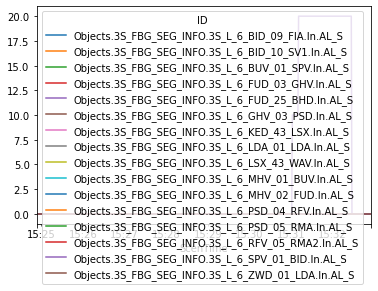

In [18]:
TCsLDSRes_AL_S.plot()

<AxesSubplot:xlabel='ScenTime'>

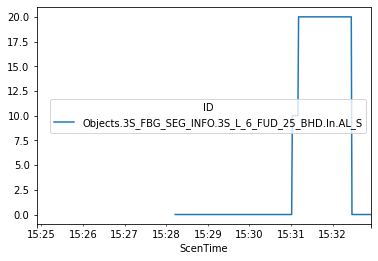

In [19]:
cols=[]
for col in TCsLDSRes_AL_S.columns:
    if TCsLDSRes_AL_S[col].max() > 0:
        cols.append(col)
TCsLDSRes_AL_S.filter(items=cols).plot()    

## Initialisierung mit H5

In [20]:
h5File=r'C:\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\Log ab 2020 11 13 14 24 54.973000.h5'

In [21]:
start = time.time()
lx=Lx.AppLog(h5File=h5File) # init with H5 (init by "connection" to previuosly parsed stuff)
end = time.time()
print(end - start)

0.03789639472961426


In [22]:
lx.lookUpDf.head()

,zipName,logName,FirstTime,LastTime
0,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000004.log,2020-11-13 14:24:54.973,2020-11-13 14:28:56.953
1,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000401.log,2020-11-14 16:34:26.229,2020-11-14 16:38:18.084
2,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000402.log,2020-11-14 16:38:18.083,2020-11-14 16:42:09.938
3,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000403.log,2020-11-14 16:42:09.936,2020-11-14 16:46:01.789
4,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000404.log,2020-11-14 16:46:01.788,2020-11-14 16:49:53.662


In [23]:
lx.lookUpDfZips.head()

,FirstTime,LastTime,TimespanPerLog,NumOfFiles,minFileNr,maxFileNr
zipName,,,,,,
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238a.7z,2020-11-13 14:24:54.973,2020-11-14 16:42:09.938,0 days 00:03:57.776293969,398,4,402
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238b.7z,2020-11-14 16:42:09.936,2020-11-15 18:49:42.568,0 days 00:03:55.720882205,399,403,802
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238c.7z,2020-11-15 18:49:42.566,2020-11-16 20:37:46.594,0 days 00:03:52.792050125,399,803,1202
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238d.7z,2020-11-16 20:37:46.593,2020-11-17 22:46:04.738,0 days 00:03:55.834949874,399,1203,1602
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238e.7z,2020-11-17 22:46:04.736,2020-11-18 07:14:58.532,0 days 00:03:42.874423357,137,1603,1740


## Initialisierung mit Zip und Lesen eines Zip-Inhalts
#### zum Lesen extrahierte Logs werden wieder geloescht wenn sie nicht existierten

In [24]:
start = time.time()
lx=Lx.AppLog(zip7File=zip7File) # init with 1st Log in zip
end = time.time()
print(end - start)

36.97447323799133


In [25]:
start = time.time()
# das Lesen und vor allem das anschließende Parsen ist noch langsam
# das wird besser, wenn Remark nicht mehr mit delimiter-Zeichen geschrieben wird; dann kann ScenTime einfacher ermittelt werden

# alle Logs werden ins H5-File geschrieben
# das H5-File kann also sehr groß werden 
# dafuer liegen dann geparste Daten vor
lx.addZip7File(zip7File) # data from zip
end = time.time()
dauer=end - start

# weitere Zips koennen auf dieselbe Art und Weise - addZip7File - hinzugefuegt werden

In [26]:
lx.lookUpDf

,zipName,logName,FirstTime,LastTime
0,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000004.log,2020-11-13 14:24:54.973,2020-11-13 14:28:56.953
1,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000005.log,2020-11-13 14:28:56.952,2020-11-13 14:32:58.997
2,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000006.log,2020-11-13 14:32:58.995,2020-11-13 14:37:01.015
3,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000400.log,2020-11-14 16:30:34.386,2020-11-14 16:34:26.231
4,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000401.log,2020-11-14 16:34:26.229,2020-11-14 16:38:18.084
5,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000402.log,2020-11-14 16:38:18.083,2020-11-14 16:42:09.938


In [27]:
print("6 logs benoetigen {!s:s} Sekunden".format(round(dauer,2)))
dauer400LogsinMinuten=round(dauer/6*400/60,2) # in einer Zip sind bei 1 GB ca. 400 Logs
print("400 logs benoetigen dann ca. {!s:s} Minuten".format(dauer400LogsinMinuten))
KalenderZeitProLogInMinuten=3.5 # Mittelwert
KalenderZeit400Logs=400*KalenderZeitProLogInMinuten
f=KalenderZeit400Logs/dauer400LogsinMinuten
print("Logs für 1 Kalendertag benoetigen dann in der Aufbereitung ca. {!s:s} Stunde(n)".format(round(24*60/f/60),2))

6 logs benoetigen 193.67 Sekunden
400 logs benoetigen dann ca. 215.19 Minuten
Logs für 1 Kalendertag benoetigen dann in der Aufbereitung ca. 4 Stunde(n)


#### Daten lesen (von H5!)

In [28]:
start = time.time()
df=lx.get() # data from H5 - ohne Parameter alles; das Ergebnis ist i.d.R. viel zu groß fuer den Arbeitsspeicher
end = time.time()
dauer=end - start
print(dauer)

8.089933395385742


In [29]:
print("eine Kalenderzeit von {!s:s} Minuten benoetigt {!s:s} Minuten zum lesen".format(KalenderZeitProLogInMinuten*6,round(dauer/60,2)))
print("eine typische Analyse-Kalenderzeit von 30 Minuten benoetigt dann {!s:s} Minuten zum lesen".format(round(30*dauer/60/(KalenderZeitProLogInMinuten*6),2)))

eine Kalenderzeit von 21.0 Minuten benoetigt 0.13 Minuten zum lesen
eine typische Analyse-Kalenderzeit von 30 Minuten benoetigt dann 0.19 Minuten zum lesen


#### Zeitreihen aus gelesenen Daten erzeugen

In [30]:
TCsdfOPC,TCsLDSIn,TCsLDSRes,TCsSirCalc=lx.getTCsFromDf(df)

In [31]:
TCsdfOPC.head()

ID,Objects.3S_STEUERUNG.3S_APP_LDS.In.LIFE,Objects.FBGL_LECK_SEG_NAME.L_6_FUD_25_BHD.SEG.RICHT.S,Objects.FBG_ESCHIEBER.6_BHD_25_MOV_07.In.ZUST,Objects.FBG_ESCHIEBER.6_ESX_25_MOV_02.In.ZUST,Objects.FBG_ESCHIEBER.6_FTV_25_MOV_04.In.ZUST,Objects.FBG_ESCHIEBER.6_FUD_25_MOV_01.In.ZUST,Objects.FBG_ESCHIEBER.6_HCX_25_MOV_06.In.ZUST,Objects.FBG_ESCHIEBER.6_WPX_25_MOV_03.In.ZUST,Objects.FBG_ESCHIEBER.7_AL1_51_MOV_100.In.ZUST,Objects.FBG_ESCHIEBER.7_NKV_44_MOV_09.In.ZUST,Objects.FBG_ESCHIEBER.7_SPV_44_MOV_10.In.ZUST,Objects.FBG_ESCHIEBER.7_URX_44_MOV_08.In.ZUST,Objects.FBG_ESCHIEBER.7_URX_52_MOV_07_1.In.ZUST,Objects.FBG_HPS.8_HND_01_PTI_01.In.MW.value,Objects.FBG_HPS.8_HND_03_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_BHD_20_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BHD_25_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BHD_26_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BID_01_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_BID_09_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_BID_10_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_FUD_02_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_FUD_25_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_KED_43_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_LPA_42_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_LSX_43_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_MHV_02_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_OHN_41_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_SPA_01_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_ZW1_20_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.7_AL1_51_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_ALD_44_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.7_EG1_03_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_LGR_01_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_LX1_50_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_SPV_44_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_URX_44_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_WAA_51_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_WSR_52_PTI_01.In.MW.value,Objects.FBG_MESSW.3_WAV_43_FT_01.In.MW.value,Objects.FBG_MESSW.4_GLD_41_PTI_01.In.MW.value,Objects.FBG_MESSW.4_SV1_10_FT_01.In.MW.value,Objects.FBG_MESSW.4_SV1_10_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ALV_10_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ANX_20_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ARV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_BHD_20_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_22_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_25_FT_01.In.MW.value,Objects.FBG_MESSW.6_BHD_25_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_26_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_01_FT_01.In.MW.value,Objects.FBG_MESSW.6_BID_01_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_09_FT_01.In.MW.value,Objects.FBG_MESSW.6_BID_09_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_10_FT_01.In.MW.value,Objects.FBG_MESSW.6_BID_10_TT_01.In.MW.value,Objects.FBG_MESSW.6_BNV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_BUV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_BUV_01_PTI_02.In.MW.value,Objects.FBG_MESSW.6_DIV_07_TT_01.In.MW.value,Objects.FBG_MESSW.6_EL1_39_FT_01.In.MW.value,Objects.FBG_MESSW.6_ENX_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ENX_01_PTI_02.In.MW.value,Objects.FBG_MESSW.6_EPX_23_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ESX_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_FTV_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_FUD_02_FT_01.In.MW.value,Objects.FBG_MESSW.6_FUD_03_TT_Z.In.MW.value,Objects.FBG_MESSW.6_FUD_25_FT_01.In.MW.value,Objects.FBG_MESSW.6_FUD_25_TT_Z.In.MW.value,Objects.FBG_MESSW.6_GHV_03_FT_02.In.MW.value,Objects.FBG_MESSW.6_GHV_03_PTI_01.In.MW.value,Objects.FBG_MESSW.6_GHV_12_PTI_01.In.MW.value,Objects.FBG_MESSW.6_GMX_22_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HAV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HCX_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HHV_05_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HSV_20_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HU1_23_PTI_01.In.MW.value,Objects.FBG_MESSW.6_KED_26_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_39_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_43_FT_01.In.MW.value,Objects.FBG_MESSW.6_KED_L1_PTI_01.In.MW.value,Objects.FBG_MESSW.6_KED_L1_PTI_03.In.MW.value,Objects.FBG_MESSW.6_KED_L1_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_L2_PTI_04.In.MW.value,Objects.FBG

<AxesSubplot:xlabel='ProcessTime'>

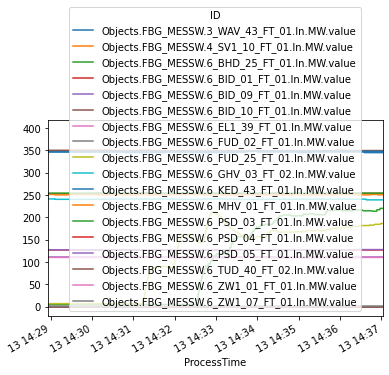

In [32]:
regExpFT=Lx.pID.pattern.replace('(?P<C4>[a-z,A-Z,0-9]+)','FT')
TCsdfOPC.filter(regex=regExpFT, axis=1).plot(xlim=('2020-11-13 14:28:56','2020-11-13 14:37:02'))

## Initialisierung mit H5

In [33]:
h5File=r'testdata\Lx\Log ab 2020 11 13 14 24 54.973000.h5'

In [34]:
start = time.time()
lx=Lx.AppLog(h5File=h5File)  # init with H5 (init by "connection" to previuosly parsed stuff)
end = time.time()
print(end - start)

0.030918598175048828


In [35]:
lx.lookUpDf.head()

,zipName,logName,FirstTime,LastTime
0,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000004.log,2020-11-13 14:24:54.973,2020-11-13 14:28:56.953
1,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000005.log,2020-11-13 14:28:56.952,2020-11-13 14:32:58.997
2,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000006.log,2020-11-13 14:32:58.995,2020-11-13 14:37:01.015
3,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000400.log,2020-11-14 16:30:34.386,2020-11-14 16:34:26.231
4,testdata\Lx\20201113_151238a - 6 Logs.7z,20201113_0000401.log,2020-11-14 16:34:26.229,2020-11-14 16:38:18.084


In [36]:
start = time.time()
df=lx.get() # data from H5 - ohne Parameter alles; das Ergebnis ist i.d.R. viel zu groß fuer den Arbeitsspeicher
end = time.time()
dauer=end - start
print(dauer)

8.159576892852783


In [37]:
df.tail()

,#LogTime,LogLevel,SubSystem,Direction,ProcessTime,ID,Value,ScenTime,State,Remark
1074743,2020-11-14 16:42:09.760,INF,OPC UA,->,2020-11-14 16:42:09.760,Objects.FBG_MESSW.4_SV1_10_FT_01.In.MW.value,302.740380,2020-11-14 17:42:07,nan,Sensor: 1605372129098 Server: 1605372129098
1074744,2020-11-14 16:42:09.760,INF,OPC UA,->,2020-11-14 16:42:09.760,Objects.FBG_MESSW.6_BID_01_FT_01.In.MW.value,135.711097,2020-11-14 17:42:07,nan,Sensor: 1605372128731 Server: 1605372128731
1074745,2020-11-14 16:42:09.760,INF,OPC UA,->,2020-11-14 16:42:09.760,Objects.FBG_MESSW.6_BID_10_FT_01.In.MW.value,394.957643,2020-11-14 17:42:07,nan,Sensor: 1605372128934 Server: 1605372128934
1074746,2020-11-14 16:42:09.760,INF,OPC UA,->,2020-11-14 16:42:09.760,Objects.FBG_MESSW.6_SKV_10_PTI_01.In.MW.value,37.157869,2020-11-14 17:42:07,nan,Sensor: 1605372129367 Server: 1605372129367
1074747,2020-11-14 16:42:09.938,STD,LOGGING,nan,NaT,nan,NaN,2020-11-14 17:42:07,nan,Next Logfile: /home/3sconsult/Logs/20201113_151238/20201113_0000403.log
